# Week 2 · Notebook 3 — Continuous Simulated Annealing and Parallel Tempering

**Goals**
- Transfer SA to $\mathbb{R}^d$: the proposal (*visiting*) distribution becomes a design choice — Gaussian
  (classical SA), Cauchy (fast SA, Szu & Hartley 1987) and the Tsallis visiting law of generalised SA
  (Tsallis & Stariolo 1996). **Prove and verify** that the Tsallis law is a Student-$t$ in disguise.
- Adapt the step size by targeting an acceptance rate; derive and verify the $0.234$ optimal-scaling result of
  Roberts, Gelman & Gilks (1997) and the $0.44$ remark for one dimension.
- Derive the replica-exchange acceptance rule of **parallel tempering** (Swendsen & Wang 1986; Geyer 1991;
  Hukushima & Nemoto 1996), verify its invariance exactly on a finite space, and verify that PT samples the correct
  marginal of a bimodal target where a single Metropolis chain fails.
- Compare SA, SA with restarts and PT (with a no-swap ablation) at an **equal evaluation budget** on Rastrigin and
  Schwefel, with multi-seed statistics.

**Prerequisites:** Notebooks 1–2 (Metropolis rule, detailed balance, schedules); Week 1 benchmark functions.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from scipy import stats
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from utils import BENCHMARKS, PALETTE

## 1. Visiting distributions

In $\mathbb{R}^d$ a proposal is $y = x + \sigma\,\xi$ with a symmetric random vector $\xi$, so the Metropolis rule of
Notebook 1 applies unchanged (symmetric proposal, no Hastings factor). The *tail* of $\xi$ decides how often SA
makes long jumps between basins:

* **Gaussian** $\xi\sim\mathcal N(0,I)$ — classical SA; with $T_k \propto 1/\log k$ (Geman & Geman 1984).
* **Cauchy** — *fast simulated annealing* (Szu & Hartley 1987): the density $\propto(1+\Vert\xi\Vert^2)^{-(d+1)/2}$ has
  infinite variance, so occasional very long jumps persist even when the scale is small. Szu & Hartley argued that
  this permits the much faster schedule $T_k = T_0/k$ (with the visiting scale proportional to $T_k$).
* **Tsallis visiting law** — *generalised SA* (GSA; Tsallis & Stariolo 1996), indexed by $q_v\in(1,3)$:

$$g_{q_v}(\Delta x) \propto \frac{T^{-d/(3-q_v)}}{\Big[1 + (q_v-1)\,\frac{\Vert\Delta x\Vert^2}{T^{2/(3-q_v)}}\Big]^{\frac{1}{q_v-1}+\frac{d-1}{2}}},
\qquad T_{q_v}(k) = T_{q_v}(1)\,\frac{2^{q_v-1}-1}{(1+k)^{q_v-1}-1}.$$

$q_v\to1$ recovers the Gaussian with a logarithmic schedule, $q_v=2$ the Cauchy law with $T\propto 1/k$.

**Proposition 1.** For $q_v\in(1,3)$, $g_{q_v}$ is the multivariate Student-$t$ law with
$\nu = (3-q_v)/(q_v-1)$ degrees of freedom and scale $s = T^{1/(3-q_v)}/\sqrt{3-q_v}$.

*Proof.* The multivariate $t_\nu$ with scale $s$ has density $\propto[1+\Vert x\Vert^2/(\nu s^2)]^{-(\nu+d)/2}$.
Matching exponents: $(\nu+d)/2 = 1/(q_v-1)+(d-1)/2 \iff \nu = 2/(q_v-1) - 1 = (3-q_v)/(q_v-1)$. Matching the
quadratic coefficients: $1/(\nu s^2) = (q_v-1)/T^{2/(3-q_v)} \iff s^2 = T^{2/(3-q_v)}/((q_v-1)\nu) =
T^{2/(3-q_v)}/(3-q_v)$. $\square$

So GSA can be sampled exactly as $\xi = z/\sqrt{w/\nu}$ with $z\sim\mathcal N(0,I_d)$, $w\sim\chi^2_\nu$ — and
$\Vert\xi\Vert^2/d \sim F(d,\nu)$, which gives an independent test of the sampler. (The popular value
$q_v = 2.62$, the default of `scipy.optimize.dual_annealing`, gives $\nu\approx0.23$: tails so heavy that not
even the mean exists.) Full GSA also generalises the acceptance rule ($q_a$); we keep the Metropolis rule so that
the only difference between variants is the visiting law and its schedule.

In [2]:
def tsallis_pdf_unnorm(x, q, T):
    return (1 + (q - 1) * x**2 / T ** (2 / (3 - q))) ** (-1 / (q - 1))   # d = 1


def t_params(q, T=1.0):
    return (3 - q) / (q - 1), T ** (1 / (3 - q)) / np.sqrt(3 - q)


xs = np.linspace(-6, 6, 13)
for q, T in [(1.5, 1.0), (2.0, 0.7), (2.62, 1.3)]:
    Zq = quad(tsallis_pdf_unnorm, -np.inf, np.inf, args=(q, T), limit=500)[0]
    nu, s = t_params(q, T)
    check_close(np.abs(tsallis_pdf_unnorm(xs, q, T) / Zq - stats.t.pdf(xs, df=nu, scale=s)).max(), 0.0,
                f"Tsallis q_v={q}, T={T} density vs Student-t(nu={nu:.3f}, scale={s:.3f}), max abs diff", atol=1e-7)


def visit(shape, kind, rng, nu=None):
    """Standardised visiting vectors xi (rows); kind in {'gauss', 'cauchy', 't'}."""
    z = rng.standard_normal(shape)
    if kind == "gauss":
        return z
    nu = 1.0 if kind == "cauchy" else nu
    w = rng.chisquare(nu, shape[:-1] + (1,))
    return z / np.sqrt(w / nu)


# Under a correct sampler the KS p-value is Uniform(0,1); we fail only below 0.001 (a 1-in-1000 false alarm).
d_test = 10
for kind, nu in [("cauchy", 1.0), ("t", t_params(2.62)[0])]:
    xi = visit((20000, d_test), kind, np.random.default_rng(1), nu)
    ks = stats.kstest(np.sum(xi**2, 1) / d_test, stats.f(d_test, nu).cdf)
    check_true(ks.pvalue > 1e-3, f"sampler '{kind}' (nu={nu:.3f}): |xi|^2/d ~ F({d_test}, nu), KS p = {ks.pvalue:.2f}")

[PASS] Tsallis q_v=1.5, T=1.0 density vs Student-t(nu=3.000, scale=0.816), max abs diff: got 0.0, expected 0.0
[PASS] Tsallis q_v=2.0, T=0.7 density vs Student-t(nu=1.000, scale=0.700), max abs diff: got 0.0, expected 0.0
[PASS] Tsallis q_v=2.62, T=1.3 density vs Student-t(nu=0.235, scale=3.236), max abs diff: got 0.0, expected 0.0
[PASS] sampler 'cauchy' (nu=1.000): |xi|^2/d ~ F(10, nu), KS p = 0.02
[PASS] sampler 't' (nu=0.235): |xi|^2/d ~ F(10, nu), KS p = 0.16


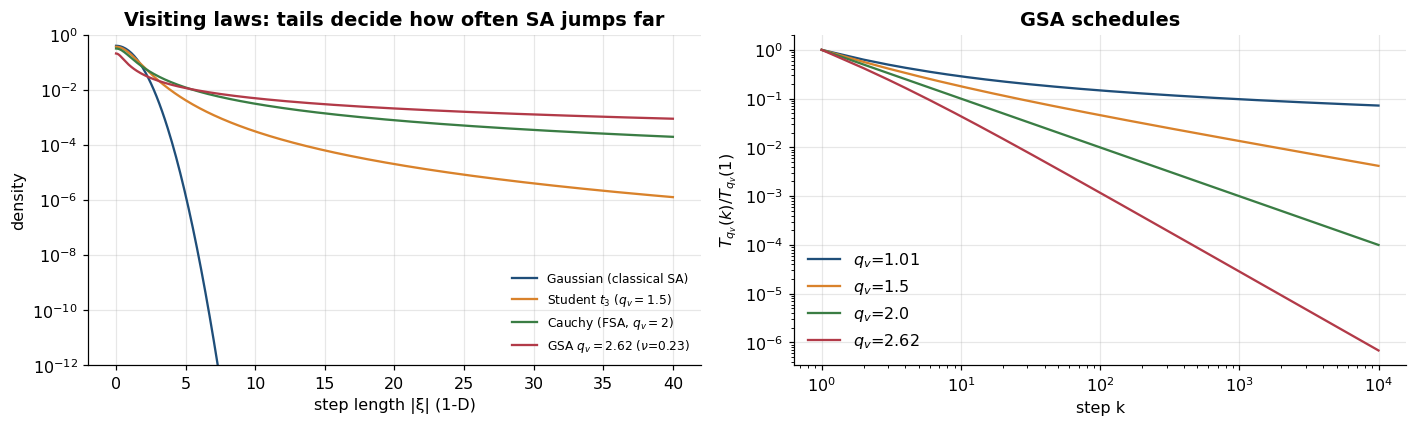

In [3]:
xg = np.linspace(0, 40, 400)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for lab, pdf in [("Gaussian (classical SA)", stats.norm.pdf(xg)),
                 (r"Student $t_3$ ($q_v=1.5$)", stats.t.pdf(xg, 3)),
                 (r"Cauchy (FSA, $q_v=2$)", stats.cauchy.pdf(xg)),
                 (rf"GSA $q_v=2.62$ ($\nu$={t_params(2.62)[0]:.2f})", stats.t.pdf(xg, t_params(2.62)[0]))]:
    ax[0].semilogy(xg, pdf, label=lab)
ax[0].set_ylim(1e-12, 1); ax[0].set_xlabel("step length |ξ| (1-D)"); ax[0].set_ylabel("density")
ax[0].set_title("Visiting laws: tails decide how often SA jumps far"); ax[0].legend(fontsize=8)
kgrid = np.arange(1, 10001)
for q in (1.01, 1.5, 2.0, 2.62):
    ax[1].loglog(kgrid, (2 ** (q - 1) - 1) / ((1 + kgrid) ** (q - 1) - 1), label=f"$q_v$={q}")
ax[1].set_xlabel("step k"); ax[1].set_ylabel(r"$T_{q_v}(k)/T_{q_v}(1)$"); ax[1].set_title("GSA schedules")
ax[1].legend()
plt.tight_layout(); savefig("w2_visiting_laws.png"); plt.show()

## 2. How large should the step be? Acceptance-rate targeting

With a fixed $T$ the step scale $\sigma$ trades acceptance for progress: tiny steps are almost always accepted but
go nowhere, huge steps are almost always rejected. For random-walk Metropolis on a product target in dimension $d$
with $\sigma = \ell/\sqrt d$, Roberts, Gelman & Gilks (1997) showed that as $d\to\infty$ each coordinate converges to
a Langevin diffusion with speed $h(\ell) = \ell^2\cdot 2\Phi(-\ell\sqrt I/2)$ and asymptotic acceptance rate
$a(\ell)=2\Phi(-\ell\sqrt I/2)$ ($I = 1$ for the standard Gaussian). Maximising $h$ gives $\ell^\ast\approx 2.38$
and **acceptance $\approx 0.234$**, independent of the target. In one dimension numerical studies give
$\approx 0.44$ (Gelman, Roberts & Gilks 1996) — the same number as Lam & Delosme's plateau in Notebook 2.

SA practitioners use these as targets for **adaptive step sizes**: after each proposal update
$\log\sigma \leftarrow \log\sigma + \gamma\,(\mathbf 1[\text{accepted}] - a^{\ast})$ (a Robbins–Monro recursion
whose fixed point has acceptance rate $a^{\ast}$). In annealing $T$ keeps falling, so $\sigma$ shrinks
automatically as the landscape "stiffens" — the step adapts to the temperature.

We verify (i) the optimisation of $h(\ell)$, (ii) the acceptance formula by simulation in $d=50$, and (iii) that
the Robbins–Monro adaptation finds $\ell^\ast$ on its own.

In [4]:
h = lambda l: l**2 * 2 * stats.norm.cdf(-l / 2)
res = minimize_scalar(lambda l: -h(l), bounds=(0.1, 6), method="bounded")
l_star, a_star = res.x, 2 * stats.norm.cdf(-res.x / 2)
check_close(l_star, 2.38, "optimal scaling l* (Roberts, Gelman & Gilks 1997)", atol=0.01)
check_close(a_star, 0.234, "optimal acceptance rate", atol=0.001)

d_rw, n_rw = 50, 6000
ells = np.array([0.5, 1.0, 1.5, 2.0, 2.38, 3.0, 4.0, 5.0, 6.0])
X = np.random.default_rng(2).standard_normal((len(ells), d_rw))    # start in stationarity
acc_count = np.zeros(len(ells))
r2 = np.random.default_rng(3)
for k in range(n_rw):
    Y = X + (ells / np.sqrt(d_rw))[:, None] * r2.standard_normal(X.shape)
    acc = np.log(r2.random(len(ells))) < 0.5 * (np.sum(X**2, 1) - np.sum(Y**2, 1))
    X[acc] = Y[acc]; acc_count += acc
emp_acc = acc_count / n_rw
check_close(emp_acc, 2 * stats.norm.cdf(-ells / 2), f"RWM acceptance in d={d_rw} vs 2Φ(-l/2)", atol=0.03)

# Robbins-Monro adaptation towards a* = 0.234, 8 independent chains
x = np.random.default_rng(4).standard_normal((8, d_rw)); log_sig = np.full(8, np.log(0.05))
r4 = np.random.default_rng(5)
for k in range(30000):
    y = x + np.exp(log_sig)[:, None] * r4.standard_normal(x.shape)
    acc = np.log(r4.random(8)) < 0.5 * (np.sum(x**2, 1) - np.sum(y**2, 1))
    x[acc] = y[acc]
    log_sig += (k + 10) ** -0.6 * (acc - 0.234)
l_hat = np.exp(log_sig) * np.sqrt(d_rw)
print("adapted l = sigma*sqrt(d) per chain:", np.round(l_hat, 2))
check_close(np.median(l_hat), l_star, "Robbins-Monro adaptation recovers l* (median over 8 chains)", atol=0.25)

[PASS] optimal scaling l* (Roberts, Gelman & Gilks 1997): got 2.381202, expected 2.38
[PASS] optimal acceptance rate: got 0.23381, expected 0.234


[PASS] RWM acceptance in d=50 vs 2Φ(-l/2): got [0.795333 0.611    0.4595   0.314833 0.235833 0.124167 0.051333 0.013833
 0.005667], expected [0.802587 0.617075 0.453255 0.317311 0.234046 0.133614 0.0455   0.012419
 0.0027  ]


adapted l = sigma*sqrt(d) per chain: [2.28 2.4  2.31 2.48 2.37 2.38 2.37 2.43]
[PASS] Robbins-Monro adaptation recovers l* (median over 8 chains): got 2.378001, expected 2.381202


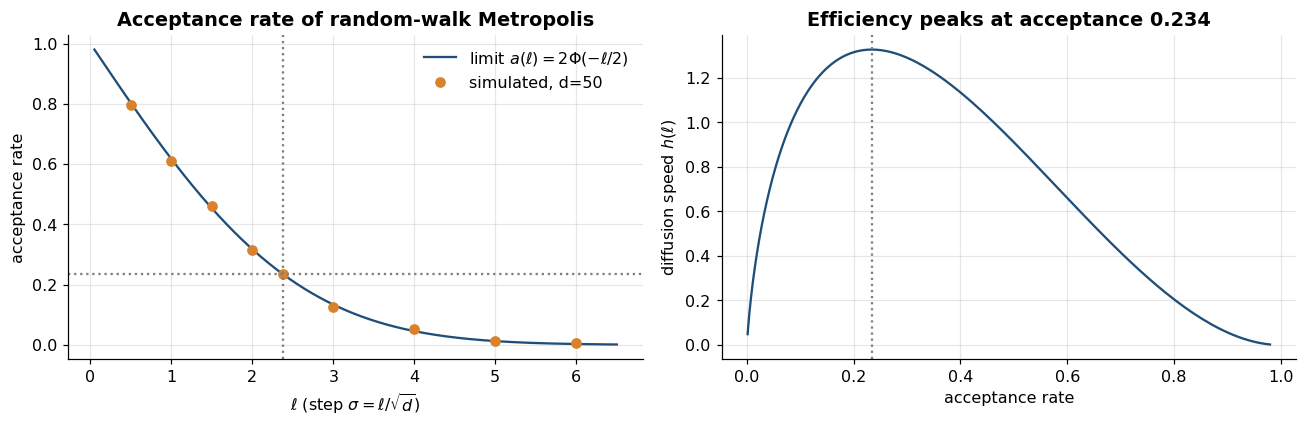

In [5]:
lg = np.linspace(0.05, 6.5, 300)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(lg, 2 * stats.norm.cdf(-lg / 2), label=r"limit $a(\ell)=2\Phi(-\ell/2)$")
ax[0].plot(ells, emp_acc, "o", label=f"simulated, d={d_rw}")
ax[0].axhline(0.234, ls=":", c="grey"); ax[0].axvline(l_star, ls=":", c="grey")
ax[0].set_xlabel(r"$\ell$ (step $\sigma=\ell/\sqrt{d}$)"); ax[0].set_ylabel("acceptance rate")
ax[0].set_title("Acceptance rate of random-walk Metropolis"); ax[0].legend()
ax[1].plot(2 * stats.norm.cdf(-lg / 2), h(lg))
ax[1].axvline(0.234, ls=":", c="grey")
ax[1].set_xlabel("acceptance rate"); ax[1].set_ylabel(r"diffusion speed $h(\ell)$")
ax[1].set_title("Efficiency peaks at acceptance 0.234")
plt.tight_layout(); savefig("w2_optimal_acceptance.png"); plt.show()

## 3. Continuous SA: implementation and comparison of visiting laws

One vectorised implementation runs $R$ independent chains (seeds) at once; every chain spends exactly one objective
evaluation per step, so "steps" = "evaluations per run". Points leaving the box $[\ell,u]^d$ are **reflected**
back (reflection keeps the proposal symmetric on the box, clipping would not: it piles mass on the boundary).

| Variant | Visiting law | Scale | Acceptance temperature |
|---|---|---|---|
| Gauss-adaptive | Gaussian | Robbins–Monro to $a^{\ast}=0.234$ | geometric $T_0\to T_0\cdot10^{-5}$ |
| Cauchy-adaptive | Cauchy | Robbins–Monro to $a^{\ast}=0.234$ | geometric, same |
| FSA (Szu & Hartley) | Cauchy | $\sigma_0\,/k$ | $T_0/k$ |
| GSA ($q_v=2.62$) | Student-$t_{0.23}$ | $\sigma_0\,[T_{q_v}(k)/T_{q_v}(1)]^{1/(3-q_v)}$ | $T_0\,T_{q_v}(k)/T_{q_v}(1)$ |
| Hill climbing | Gaussian, adaptive | as Gauss-adaptive | $T=0$ |

$\sigma_0 = 0.1(u-\ell)$; $T_0$ is set from a target uphill acceptance of $\chi_0=0.8$ for $\sigma_0$-steps from
random points (Notebook 2). Budget: $2\times10^4$ evaluations, $d=10$, 15 seeds.

In [6]:
def reflect(Y, lo, hi):
    """Reflect coordinates into [lo, hi] (triangle-wave folding, works for arbitrarily long jumps)."""
    w = hi - lo
    z = np.mod(Y - lo, 2 * w)
    return lo + np.where(z > w, 2 * w - z, z)


def estimate_T0(f, lo, hi, d, sigma, chi0, rng, M=2000):
    X = rng.uniform(lo, hi, (M, d))
    Y = reflect(X + sigma * rng.standard_normal((M, d)), lo, hi)
    dlt = f(Y) - f(X)
    up = dlt[dlt > 0]
    from scipy.optimize import brentq
    return brentq(lambda T: np.mean(np.exp(-up / T)) - chi0, 1e-9, 1e9)


def continuous_sa(f, lo, hi, d, budget, R, rng, variant="gauss", T0=1.0, sigma0=1.0, a_target=0.234,
                  T_end_ratio=1e-5, q_v=2.62, X0=None):
    """R parallel SA chains in [lo,hi]^d. Returns best f per chain and a best-so-far trace (R x 100)."""
    X = rng.uniform(lo, hi, (R, d)) if X0 is None else X0.copy()
    fX = f(X); best = fX.copy(); evals = 1
    log_sig = np.full(R, np.log(sigma0))
    alpha = T_end_ratio ** (1 / budget)
    nu = (3 - q_v) / (q_v - 1)
    Tq1 = 1.0
    trace, marks = [], set(np.linspace(1, budget, 100).astype(int))
    for k in range(1, budget):
        if variant in ("gauss", "cauchy", "hc"):
            T = T0 * alpha**k
            sig = np.exp(log_sig)[:, None]
            xi = visit((R, d), "cauchy" if variant == "cauchy" else "gauss", rng)
        elif variant == "fsa":
            T, sig = T0 / k, sigma0 / k
            xi = visit((R, d), "cauchy", rng)
        elif variant == "gsa":
            Tq = (2 ** (q_v - 1) - 1) / ((1 + k) ** (q_v - 1) - 1) / Tq1
            T, sig = T0 * Tq, sigma0 * Tq ** (1 / (3 - q_v))
            xi = visit((R, d), "t", rng, nu)
        Y = reflect(X + sig * xi, lo, hi)
        fY = f(Y); evals += 1
        dlt = fY - fX
        if variant == "hc":
            acc = dlt <= 0
        else:
            acc = (dlt <= 0) | (rng.random(R) < np.exp(-np.maximum(dlt, 0) / T))
        X[acc], fX[acc] = Y[acc], fY[acc]
        np.minimum(best, fX, out=best)
        if variant in ("gauss", "cauchy", "hc"):
            log_sig += 0.02 * (acc - a_target)
        if k + 1 in marks:
            trace.append(best.copy())
    assert evals == budget
    return best, np.array(trace).T

**Validation on closed forms.** On the sphere $f(x)=\Vert x\Vert^2$ the Boltzmann law at temperature $T$ is
$\pi_T\propto e^{-\Vert x\Vert^2/T}$, i.e. $x_i\sim\mathcal N(0,T/2)$ independently, so at stationarity
$\mathbb E_{\pi_T}[f] = dT/2$ (equipartition). (i) At a *fixed* temperature the chain's time-averaged energy must
match $dT/2$ — this also tells us that an SA run ending at $T_{\text{end}}$ cannot be expected to get much below
$dT_{\text{end}}/2$. (ii) With $T_{\text{end}} = 10^{-9}T_0$ the adaptive Gaussian SA must reach the optimum
$f^\ast = 0$ to high precision.

In [7]:
bs = BENCHMARKS["sphere"]
# (i) equipartition at fixed T = 0.05 (8 chains started at stationarity, 20000 steps, adaptive step)
T_fix, n_eq = 0.05, 20000
x = np.random.default_rng(6).normal(0, np.sqrt(T_fix / 2), (8, 10)); fx = bs.f(x)
f_hist = np.empty((n_eq, 8))
ls_, r6 = np.full(8, np.log(0.1)), np.random.default_rng(7)
for k in range(n_eq):
    y = x + np.exp(ls_)[:, None] * r6.standard_normal(x.shape); fy = bs.f(y)
    acc = r6.random(8) < np.exp(-np.maximum(fy - fx, 0) / T_fix)
    x[acc], fx[acc] = y[acc], fy[acc]
    ls_ += (k + 10) ** -0.6 * (acc - 0.234)
    f_hist[k] = fx
# standard error: 8 independent chains x 40 batch means each (batch length 500 >> autocorrelation time)
bm = f_hist.reshape(40, -1, 8).mean(1).ravel()
f_mean, f_se = bm.mean(), bm.std(ddof=1) / np.sqrt(bm.size)
check_close(f_mean, 10 * T_fix / 2, f"time-averaged f at fixed T equals equipartition d*T/2 (4 s.e. = {4 * f_se:.4f})",
            atol=4 * f_se, rtol=0)
# (ii) annealing to 1e-9 T0
T0s = estimate_T0(bs.f, bs.lower, bs.upper, 10, 0.1 * (bs.upper - bs.lower), 0.8, np.random.default_rng(6))
best_s, _ = continuous_sa(bs.f, bs.lower, bs.upper, 10, 20000, 10, np.random.default_rng(7), "gauss",
                          T0=T0s, sigma0=0.1 * (bs.upper - bs.lower), T_end_ratio=1e-9)
print(f"sphere d=10: T0 = {T0s:.3g}, T_end = {T0s * 1e-9:.2g}, worst final f over 10 seeds = {best_s.max():.2e}")
check_true(best_s.max() < 1e-6, "adaptive Gaussian SA reaches f(x*) = 0 on the sphere (all seeds, f < 1e-6)")

[PASS] time-averaged f at fixed T equals equipartition d*T/2 (4 s.e. = 0.0066): got 0.249556, expected 0.25


sphere d=10: T0 = 54.8, T_end = 5.5e-08, worst final f over 10 seeds = 1.35e-07
[PASS] adaptive Gaussian SA reaches f(x*) = 0 on the sphere (all seeds, f < 1e-6)


In [8]:
funcs = ["rastrigin", "ackley", "schwefel"]
variants = {"Gauss-adaptive": "gauss", "Cauchy-adaptive": "cauchy", "FSA (Szu-Hartley)": "fsa",
            "GSA q_v=2.62": "gsa", "Hill climbing": "hc"}
d, budget, R = 10, 20000, 15
cont = {}
for fn in funcs:
    b = BENCHMARKS[fn]
    sig0 = 0.1 * (b.upper - b.lower)
    T0 = estimate_T0(b.f, b.lower, b.upper, d, sig0, 0.8, np.random.default_rng(8))
    X0 = np.random.default_rng(9).uniform(b.lower, b.upper, (R, d))           # common starting points
    for vn, v in variants.items():
        best, tr = continuous_sa(b.f, b.lower, b.upper, d, budget, R, np.random.default_rng(10), v,
                                 T0=T0, sigma0=sig0, X0=X0)
        cont[fn, vn] = best - b.f_opt
    print(f"{fn:10s} T0 = {T0:9.3g} | " + " | ".join(
        f"{vn}: {np.median(cont[fn, vn]):.3g} [{np.percentile(cont[fn, vn], 25):.3g}, {np.percentile(cont[fn, vn], 75):.3g}]"
        for vn in variants))

rastrigin  T0 =       113 | Gauss-adaptive: 29.9 [27.4, 34.3] | Cauchy-adaptive: 29.9 [24.4, 36.8] | FSA (Szu-Hartley): 69.7 [67.2, 78.1] | GSA q_v=2.62: 103 [97.8, 108] | Hill climbing: 46.8 [34.3, 58.2]


ackley     T0 =      1.33 | Gauss-adaptive: 9.28e-05 [8e-05, 0.823] | Cauchy-adaptive: 9.3e-05 [8.38e-05, 1.4] | FSA (Szu-Hartley): 19.2 [18.9, 19.4] | GSA q_v=2.62: 19.7 [18.9, 20] | Hill climbing: 4.44e-16 [4.44e-16, 0.823]


schwefel   T0 =  2.66e+03 | Gauss-adaptive: 1.05e+03 [869, 1.2e+03] | Cauchy-adaptive: 1.19e+03 [967, 1.31e+03] | FSA (Szu-Hartley): 1.78e+03 [1.46e+03, 2.34e+03] | GSA q_v=2.62: 2.62e+03 [2.33e+03, 2.96e+03] | Hill climbing: 1.9e+03 [1.55e+03, 2.14e+03]


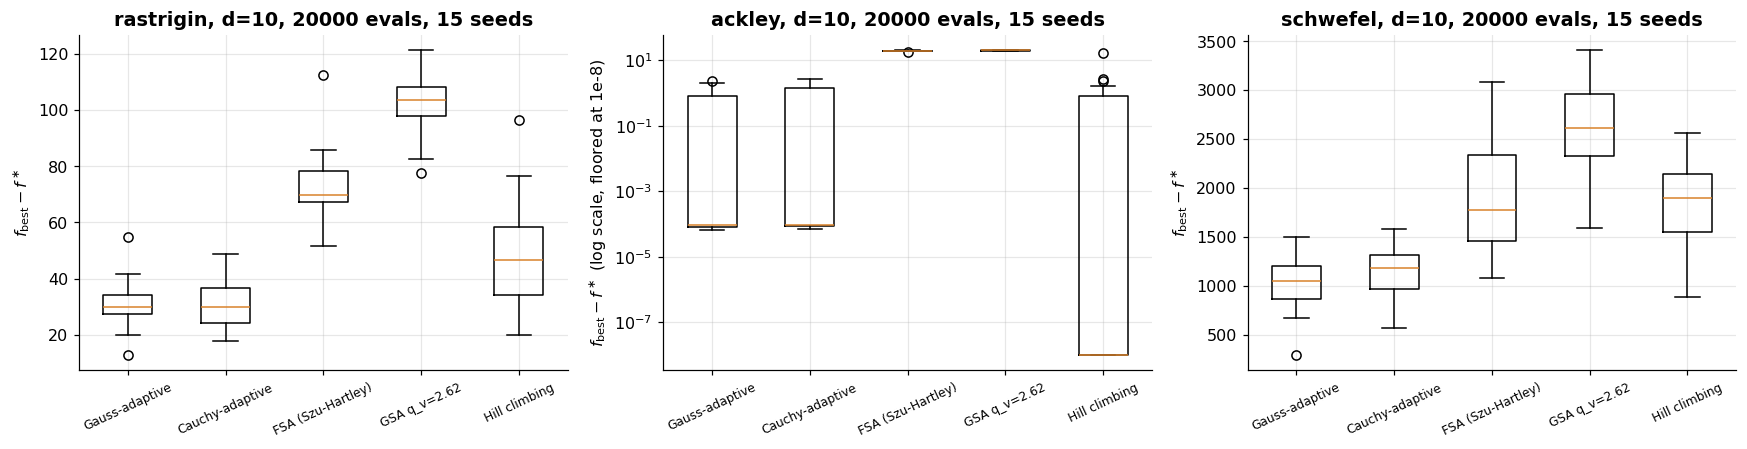

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for a, fn in zip(ax, funcs):
    data = [np.maximum(cont[fn, vn], 1e-8) for vn in variants]
    a.boxplot(data, vert=True)
    a.set_xticks(range(1, len(variants) + 1), list(variants), rotation=25, fontsize=8)
    if fn == "ackley":                     # spans 16 decades; the other two span less than one
        a.set_yscale("log"); a.set_ylabel(r"$f_{\mathrm{best}} - f^\ast$ (log scale, floored at 1e-8)")
    else:
        a.set_ylabel(r"$f_{\mathrm{best}} - f^\ast$")
    a.set_title(f"{fn}, d={d}, {budget} evals, {R} seeds")
plt.tight_layout(); savefig("w2_continuous_sa.png"); plt.show()

**Reading the results** (medians and IQRs printed above).

* The two **adaptive** variants are the robust ones and are statistically similar to each other (Rastrigin: median
  29.9 for both, vs 46.8 for hill climbing): because the scale follows the acceptance rate, they need no prior
  knowledge of the right step size at any temperature.
* **FSA** and **GSA** tie the step size to a *fixed* clock ($\sigma_0/k$, or $\sigma_0 T_{q_v}(k)^{1/(3-q_v)}$, which
  for $q_v=2.62$ decays like $k^{-4.3}$). With the problem-independent clock the scale collapses within the first
  few hundred steps and the runs freeze far from any good basin — they end *worse than hill climbing* on Rastrigin
  and Ackley (and GSA also on Schwefel). Their convergence theory concerns the limit $k\to\infty$ and says nothing about a
  $2\times10^4$-evaluation budget; in practice (e.g. `dual_annealing`) GSA is combined with restarts and local search.
* **Ackley** is a global funnel with small ripples: hill climbing with adaptive steps reaches the optimum to machine
  precision in more than half of the runs, while SA's median stalls near $10^{-4}$ — the *thermal floor* set by
  $T_{\text{end}} = 10^{-5}T_0\approx 1.3\times10^{-5}$. Near its minimum Ackley is a cone, $f\approx c\Vert x\Vert$, and for
  $\pi_T\propto e^{-c\Vert x\Vert/T}$ one finds $\mathbb E_{\pi_T}[f] = dT$ (the radial law is a Gamma$(d, T/c)$) —
  about $1.3\times10^{-4}$ here, the order of magnitude observed; for the quadratic bowl it is the $dT/2$ verified
  above. Annealing buys nothing on a
  funnel; it costs final precision unless $T_{\text{end}}$ is tiny or a local search polishes the result.
* **Schwefel** is deceptive — its best basin sits near the corner $x_i\approx 420.97$, far from the second-best
  basins — and no variant gets close to $f^\ast$ in $d=10$ within this budget.

## 4. Parallel tempering (replica exchange)

PT (anticipated by the replica Monte Carlo of Swendsen & Wang 1986 for spin glasses; Geyer 1991 as
"Metropolis-coupled MCMC"; Hukushima & Nemoto 1996 as "exchange Monte Carlo") runs $M$ replicas at inverse temperatures $\beta_1 \gt \beta_2 \gt\dots\gt\beta_M$ on the
**product target** $\Pi(x_1,\dots,x_M) = \prod_m \pi_{\beta_m}(x_m)$, $\pi_\beta \propto e^{-\beta E}$. Each sweep
(i) updates every replica with its own Metropolis kernel (which leaves $\Pi$ invariant factor by factor), then
(ii) proposes to **swap** the states of neighbouring replicas $i, j$. The swap proposal is symmetric (a deterministic
involution), so the Metropolis–Hastings ratio is

$$\frac{\Pi(\dots,x_j,\dots,x_i,\dots)}{\Pi(\dots,x_i,\dots,x_j,\dots)} =
\frac{e^{-\beta_i E(x_j)}e^{-\beta_j E(x_i)}}{e^{-\beta_i E(x_i)}e^{-\beta_j E(x_j)}}
= e^{(\beta_i - \beta_j)(E(x_i) - E(x_j))},$$

and we accept with probability $\min\big(1, e^{(\beta_i-\beta_j)(E_i-E_j)}\big)$ — no new evaluations needed. A swap is
always accepted if the hotter replica holds the lower energy. The cold replica thus receives states found by hot
replicas that cross barriers freely, while each marginal remains exactly $\pi_{\beta_m}$.

```text
ParallelTempering(β_1 > ... > β_M, sweeps):
    for each sweep:
        for m = 1..M:  x_m <- MetropolisStep(x_m, β_m)          # M evaluations
        for pairs (m, m+1) with m even (odd on alternate sweeps):
            if U < exp((β_m - β_{m+1}) (E_m - E_{m+1})):  swap x_m <-> x_{m+1}
```

**Exact check on a finite space.** Two replicas on a 6-state ring; the full PT kernel on the $36$ joint states is
$K = (P_{\beta_1}\otimes P_{\beta_2})\,S$ with the swap kernel $S$. Its stationary vector (eigenvector, independent
of the formula) must equal $\pi_{\beta_1}\otimes\pi_{\beta_2}$, and a sign error in the exchange rule must break it.

In [10]:
E6 = np.array([0.0, 2.0, 1.0, 3.0, 0.5, 2.5])
n6 = len(E6)


def metro_ring(E, beta):
    n = len(E); P = np.zeros((n, n))
    for i in range(n):
        for j in ((i - 1) % n, (i + 1) % n):
            P[i, j] += 0.5 * min(1.0, np.exp(-beta * (E[j] - E[i])))
        P[i, i] = 1 - P[i].sum()
    return P


def swap_kernel(E, b1, b2, sign=+1):
    n = len(E); S = np.zeros((n * n, n * n))
    for a in range(n):
        for c in range(n):
            acc = min(1.0, np.exp(sign * (b1 - b2) * (E[a] - E[c])))
            S[a * n + c, c * n + a] += acc
            S[a * n + c, a * n + c] += 1 - acc
    return S


def gibbs(E, beta):
    w = np.exp(-beta * (E - E.min())); return w / w.sum()


def stationary(P):
    w, V = np.linalg.eig(P.T); v = np.real(V[:, np.argmin(np.abs(w - 1))]); return v / v.sum()


b1, b2 = 2.0, 0.5
target = np.outer(gibbs(E6, b1), gibbs(E6, b2)).ravel()
K_ok = np.kron(metro_ring(E6, b1), metro_ring(E6, b2)) @ swap_kernel(E6, b1, b2, +1)
K_bad = np.kron(metro_ring(E6, b1), metro_ring(E6, b2)) @ swap_kernel(E6, b1, b2, -1)
check_close(np.abs(stationary(K_ok) - target).max(), 0.0, "PT kernel leaves pi_b1 x pi_b2 invariant (max abs diff)", atol=1e-12)
tv_bad = 0.5 * np.abs(stationary(K_bad) - target).sum()
check_true(tv_bad > 0.05, f"sign error in the exchange rule breaks it (TV = {tv_bad:.3f})")

[PASS] PT kernel leaves pi_b1 x pi_b2 invariant (max abs diff): got 0.0, expected 0.0
[PASS] sign error in the exchange rule breaks it (TV = 0.586)


**Continuous check: a bimodal target.** $E(x) = 16(x^2-1)^2 + 0.4x$ on $\mathbb{R}$ has two wells separated by a
barrier of height $\approx 16$; at $\beta=1$ the left well carries most, but not all, of the mass. We compare, over
$4\times10^4$ sweeps: a single Metropolis chain at $\beta=1$ started in the right well, and PT with a geometric ladder
of $M=7$ inverse temperatures from $1$ to $1/32$. Reference: $\Pr_\beta(X\lt0)$ by numerical quadrature for every
$\beta$ of the ladder. Monte Carlo standard errors are estimated by batch means (50 batches).

In [11]:
U = lambda x: 16 * (x**2 - 1) ** 2 + 0.4 * x
M_pt = 7
betas = 1.0 / np.geomspace(1, 32, M_pt)
exact_left = np.array([quad(lambda x: np.exp(-b * U(x)), -np.inf, 0)[0] / quad(lambda x: np.exp(-b * U(x)), -np.inf, np.inf)[0]
                       for b in betas])


def pt_sample(U, betas, n_sweeps, x0, step, rng, swaps=True):
    M = len(betas); x = np.full(M, x0, dtype=float); ux = U(x)
    left = np.zeros((n_sweeps, M), dtype=bool); samples0 = np.empty(n_sweeps)
    n_try = n_acc = 0
    for t in range(n_sweeps):
        y = x + step * rng.standard_normal(M); uy = U(y)
        acc = np.log(rng.random(M)) < -betas * (uy - ux)
        x[acc], ux[acc] = y[acc], uy[acc]
        if swaps:
            for m in range(t % 2, M - 1, 2):
                n_try += 1
                if np.log(rng.random()) < (betas[m] - betas[m + 1]) * (ux[m] - ux[m + 1]):
                    x[[m, m + 1]], ux[[m, m + 1]] = x[[m + 1, m]], ux[[m + 1, m]]
                    n_acc += 1
        left[t] = x < 0; samples0[t] = x[0]
    return left, samples0, (n_acc / max(n_try, 1))


n_sweeps, burn = 40000, 4000
steps_ = 0.4 * np.sqrt(1 / betas)                        # wider steps for hotter replicas
left_pt, s_pt, swap_rate = pt_sample(U, betas, n_sweeps, 1.0, steps_, np.random.default_rng(11))
left_1, s_1, _ = pt_sample(U, betas[:1], n_sweeps, 1.0, steps_[:1], np.random.default_rng(12), swaps=False)
est = left_pt[burn:].mean(0)
batches = left_pt[burn:].reshape(50, -1, M_pt).mean(1)
se = batches.std(0, ddof=1) / np.sqrt(50)
print("beta:           ", np.round(betas, 3))
print("exact P(X<0):   ", np.round(exact_left, 4))
print("PT estimate:    ", np.round(est, 4), "\nbatch-means s.e.", np.round(se, 4))
print(f"single chain at beta=1: P(X<0) = {left_1[burn:].mean():.4f};  PT swap acceptance = {swap_rate:.2f}")
check_true(np.all(np.abs(est - exact_left) < 4 * se + 1e-3), "PT marginals match quadrature at every beta (4 s.e.)")
check_true(abs(left_1[burn:].mean() - exact_left[0]) > 0.3, "single Metropolis chain at beta=1 is badly wrong (> 0.3 off)")

beta:            [1.    0.561 0.315 0.177 0.099 0.056 0.031]
exact P(X<0):    [0.6878 0.6078 0.5596 0.5318 0.5169 0.5092 0.5052]
PT estimate:     [0.6934 0.6109 0.5617 0.5283 0.5115 0.5022 0.5002] 
batch-means s.e. [0.0075 0.0073 0.006  0.0049 0.0039 0.0032 0.0035]
single chain at beta=1: P(X<0) = 0.0000;  PT swap acceptance = 0.82
[PASS] PT marginals match quadrature at every beta (4 s.e.)
[PASS] single Metropolis chain at beta=1 is badly wrong (> 0.3 off)


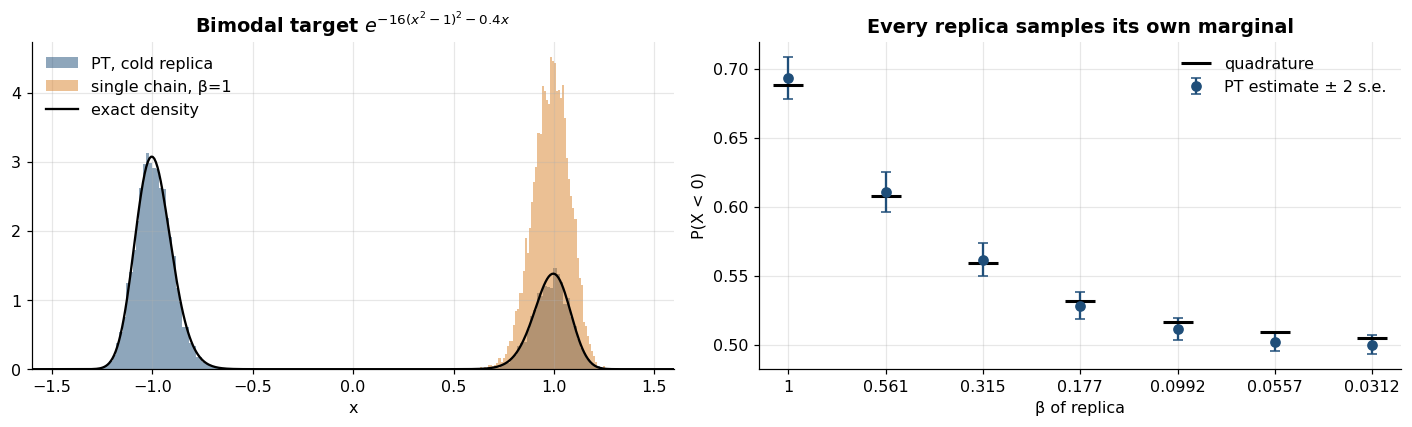

In [12]:
xgrid = np.linspace(-1.6, 1.6, 400)
dens = np.exp(-U(xgrid)); dens /= np.trapezoid(dens, xgrid)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(s_pt[burn:], bins=160, density=True, alpha=0.5, label="PT, cold replica")
ax[0].hist(s_1[burn:], bins=80, density=True, alpha=0.5, label="single chain, β=1")
ax[0].plot(xgrid, dens, "k", lw=1.5, label="exact density")
ax[0].set_xlim(-1.6, 1.6); ax[0].set_xlabel("x"); ax[0].set_title(r"Bimodal target $e^{-16(x^2-1)^2-0.4x}$"); ax[0].legend()
ax[1].errorbar(np.arange(M_pt), est, yerr=2 * se, fmt="o", capsize=3, label="PT estimate ± 2 s.e.")
ax[1].plot(np.arange(M_pt), exact_left, "k_", ms=20, mew=2, label="quadrature")
ax[1].set_xticks(np.arange(M_pt), [f"{b:.3g}" for b in betas]); ax[1].set_xlabel("β of replica")
ax[1].set_ylabel("P(X < 0)"); ax[1].set_title("Every replica samples its own marginal"); ax[1].legend()
plt.tight_layout(); savefig("w2_parallel_tempering.png"); plt.show()

## 5. PT versus SA versus restarts at equal budgets

As an **optimiser**, PT keeps the whole temperature ladder alive for the whole run and reports the best point
seen by any replica. We compare, at $B = 4\times10^4$ evaluations per run, $d=10$, 15 seeds:

* **SA**: one Gauss-adaptive chain, geometric $T_0\to T_0\cdot10^{-5}$;
* **SA + restarts**: 8 independent SA runs of $5000$ evaluations each (same schedule compressed);
* **PT**: $M=8$ replicas $\times$ 5000 sweeps, temperatures geometric between $T_0\cdot10^{-5}$ and $T_0$, each replica
  with its own Robbins–Monro step size, even/odd swaps every sweep;
* **PT without swaps** — the ablation: 8 independent fixed-temperature chains. The difference PT − ablation is
  exactly what the exchange mechanism contributes.

$T_0$ as in Section 3. Pairwise differences are tested with the Mann–Whitney $U$ test (independent samples).

In [13]:
def pt_optimize(f, lo, hi, d, budget, M, T_min, T_max, sigma0, R, rng, swaps=True, a_target=0.234):
    """R independent PT runs in parallel (arrays R x M x d); returns best f per run."""
    sweeps = budget // M
    Ts = np.geomspace(T_min, T_max, M); bet = 1 / Ts
    X = rng.uniform(lo, hi, (R, M, d)); fX = f(X.reshape(-1, d)).reshape(R, M)
    best = fX.min(1); log_sig = np.full((R, M), np.log(sigma0)); evals = M
    rows = np.arange(R)
    for t in range(1, sweeps):
        Y = reflect(X + np.exp(log_sig)[..., None] * rng.standard_normal(X.shape), lo, hi)
        fY = f(Y.reshape(-1, d)).reshape(R, M); evals += M
        acc = rng.random((R, M)) < np.exp(-np.maximum(fY - fX, 0) * bet)
        X[acc], fX[acc] = Y[acc], fY[acc]
        log_sig += 0.02 * (acc - a_target)
        np.minimum(best, fX.min(1), out=best)
        if swaps:
            for m in range(t % 2, M - 1, 2):
                ok = np.log(rng.random(R)) < (bet[m] - bet[m + 1]) * (fX[:, m] - fX[:, m + 1])
                idx = rows[ok]
                X[idx, m], X[idx, m + 1] = X[idx, m + 1].copy(), X[idx, m].copy()
                fX[idx, m], fX[idx, m + 1] = fX[idx, m + 1].copy(), fX[idx, m].copy()
    assert evals == budget
    return best


def sa_restarts(f, lo, hi, d, budget, n_restarts, R, rng, T0, sigma0):
    per = budget // n_restarts
    best = np.full(R, np.inf)
    for _ in range(n_restarts):
        b, _ = continuous_sa(f, lo, hi, d, per, R, rng, "gauss", T0=T0, sigma0=sigma0)
        best = np.minimum(best, b)
    return best


B, R2, M8 = 40000, 15, 8
cmp_res = {}
for fn in ["rastrigin", "schwefel"]:
    b = BENCHMARKS[fn]; sig0 = 0.1 * (b.upper - b.lower)
    T0 = estimate_T0(b.f, b.lower, b.upper, d, sig0, 0.8, np.random.default_rng(8))
    cmp_res[fn, "SA"] = continuous_sa(b.f, b.lower, b.upper, d, B, R2, np.random.default_rng(20), "gauss",
                                      T0=T0, sigma0=sig0)[0] - b.f_opt
    cmp_res[fn, "SA + 8 restarts"] = sa_restarts(b.f, b.lower, b.upper, d, B, 8, R2, np.random.default_rng(21), T0, sig0) - b.f_opt
    cmp_res[fn, "PT (8 replicas)"] = pt_optimize(b.f, b.lower, b.upper, d, B, M8, T0 * 1e-5, T0, sig0, R2,
                                                 np.random.default_rng(22)) - b.f_opt
    cmp_res[fn, "PT, no swaps"] = pt_optimize(b.f, b.lower, b.upper, d, B, M8, T0 * 1e-5, T0, sig0, R2,
                                              np.random.default_rng(22), swaps=False) - b.f_opt
methods_c = ["SA", "SA + 8 restarts", "PT (8 replicas)", "PT, no swaps"]
raw_p = {(fn, m): stats.mannwhitneyu(cmp_res[fn, m], cmp_res[fn, "PT (8 replicas)"]).pvalue
         for fn in ["rastrigin", "schwefel"] for m in methods_c if m != "PT (8 replicas)"}
order_p = sorted(raw_p, key=raw_p.get)                       # Holm (1979) step-down over all 6 tests
holm_p, running = {}, 0.0
for i, key in enumerate(order_p):
    running = max(running, min(1.0, (len(order_p) - i) * raw_p[key])); holm_p[key] = running
for fn in ["rastrigin", "schwefel"]:
    print(f"--- {fn}, d={d}, budget {B}, {R2} seeds: median [IQR] of f_best - f*")
    for m in methods_c:
        v = cmp_res[fn, m]
        p = "" if m == "PT (8 replicas)" else f"   Mann-Whitney p vs PT = {raw_p[fn, m]:.2g} (Holm {holm_p[fn, m]:.2g})"
        print(f"  {m:16s} {np.median(v):9.3g} [{np.percentile(v, 25):8.3g}, {np.percentile(v, 75):8.3g}]{p}")

--- rastrigin, d=10, budget 40000, 15 seeds: median [IQR] of f_best - f*
  SA                    27.9 [    24.4,     33.3]   Mann-Whitney p vs PT = 0.0021 (Holm 0.013)
  SA + 8 restarts       16.9 [    13.4,     19.9]   Mann-Whitney p vs PT = 0.93 (Holm 1)
  PT (8 replicas)       17.9 [    12.9,     21.4]
  PT, no swaps          21.4 [    18.9,     24.5]   Mann-Whitney p vs PT = 0.089 (Holm 0.27)
--- schwefel, d=10, budget 40000, 15 seeds: median [IQR] of f_best - f*
  SA                     989 [     819, 1.21e+03]   Mann-Whitney p vs PT = 0.018 (Holm 0.072)
  SA + 8 restarts        811 [     632,      888]   Mann-Whitney p vs PT = 0.59 (Holm 1)
  PT (8 replicas)        691 [     661,      898]
  PT, no swaps           931 [     834, 1.16e+03]   Mann-Whitney p vs PT = 0.0055 (Holm 0.027)


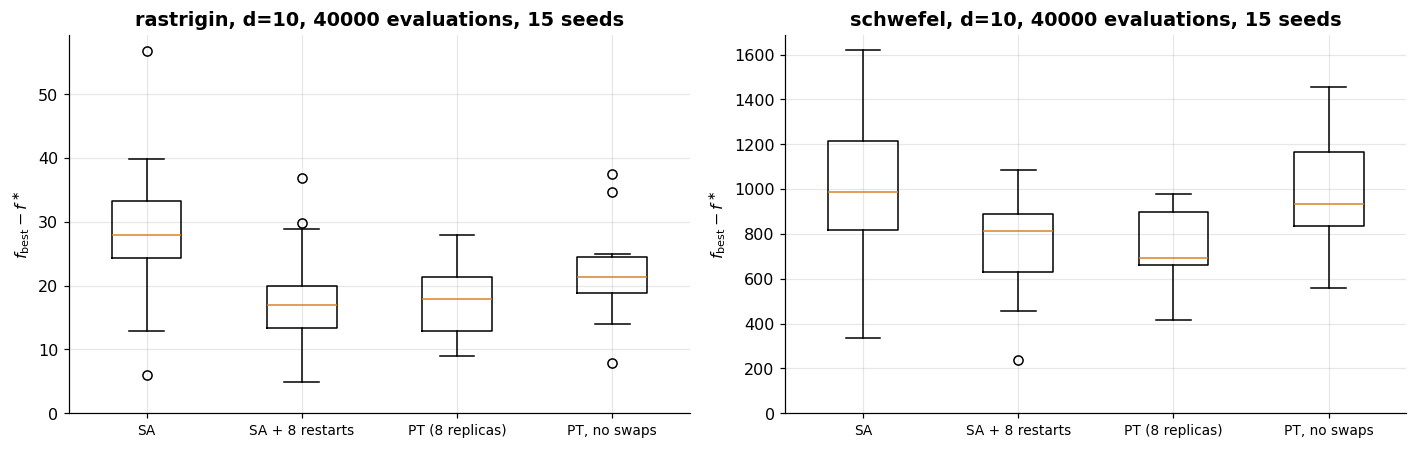

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for a, fn in zip(ax, ["rastrigin", "schwefel"]):
    a.boxplot([np.maximum(cmp_res[fn, m], 1e-8) for m in methods_c])
    a.set_xticks(range(1, 5), methods_c, fontsize=9); a.set_ylim(bottom=0)
    a.set_ylabel(r"$f_{\mathrm{best}}-f^\ast$"); a.set_title(f"{fn}, d={d}, {B} evaluations, {R2} seeds")
plt.tight_layout(); savefig("w2_pt_vs_sa.png"); plt.show()

**Reading the results** (numbers above).

Six tests are made, so we also report Holm-adjusted $p$-values (family-wise error rate 5%).

* **PT beats a single SA run** on both functions at the same budget (Mann–Whitney $p = 0.002$ on Rastrigin,
  Holm-adjusted $0.013$; $p = 0.02$ on Schwefel, which is only suggestive after adjustment, Holm $0.07$).
* **PT and SA with 8 restarts are statistically indistinguishable** ($p = 0.93$ and $0.59$): both spread the budget
  over 8 trajectories, and on these landscapes diversification is what matters.
* **The ablation isolates the exchange mechanism.** PT and "PT, no swaps" use identical replicas, temperatures,
  starting points and budgets; swaps help clearly on Schwefel ($p = 0.006$, Holm $0.027$) and at most weakly on
  Rastrigin ($p = 0.09$). The hot replicas do find better basins, but only swaps deliver them to the cold replicas
  that can exploit them.
* PT's decisive advantage is as a **sampler** (Section 4): SA and restarts give no correct answer to "what is
  $\Pr_{\beta=1}(X\lt0)$?" at all, while PT does, with error bars.

**AI relevance.** Replica exchange is used for sampling Bayesian neural-network posteriors and energy-based
models. Population-based training (Jaderberg et al. 2017) shares PT's structure loosely — a population of runs with
different hyperparameters (learning rates, exploration noise) that periodically copy each other's states — although
its exploit/explore step is a greedy selection, not a detailed-balance exchange.
Heavy-tailed proposals appear in evolution strategies and in Lévy-flight exploration for RL.

## Key takeaways

- In continuous spaces SA's proposal law is a design choice: Gaussian, Cauchy (FSA) or Tsallis (GSA) — and the
  Tsallis law is exactly a multivariate Student-$t$ with $\nu = (3-q_v)/(q_v-1)$, which gives an exact sampler.
- Step sizes should be adapted to an acceptance target; $0.234$ (high $d$) and $0.44$ (1-D) come from optimal
  scaling theory, which we reproduced (optimum $\ell^\ast = 2.38$, simulated acceptance curve, Robbins–Monro).
- Clock-driven step/temperature laws (FSA, GSA) come with limit theorems, not finite-budget guarantees; adaptive
  variants are more robust.
- Parallel tempering's exchange rule $\min(1, e^{(\beta_i-\beta_j)(E_i-E_j)})$ preserves the product of Boltzmann
  laws (verified exactly), and PT samples a bimodal target correctly where one chain fails completely.
- As an optimiser, PT must be judged at equal evaluation budgets against SA and restarts, with an ablation of the
  swap mechanism.

## Exercises

1. ★ Show that the Tsallis visiting law has finite variance iff $q_v\lt 5/3$ and a finite mean iff $q_v\lt 2$
   (use Proposition 1). What does this imply for $q_v = 2.62$?
2. ★ Prove that reflecting proposals into a box $[\ell,u]^d$ preserves the symmetry $q(x,y)=q(y,x)$ for a
   Gaussian random walk, whereas clipping does not. Verify numerically with a histogram of a fixed-$T$ chain on a
   1-D box with $E\equiv0$ (the target is uniform).
3. ★★ For PT with two replicas whose stationary energies are Gaussian, $E\sim\mathcal N(\mu(\beta),\sigma^2(\beta))$, with
   $\beta_1-\beta_2$ small, derive the mean swap acceptance rate and show that it depends only on
   $(\beta_1-\beta_2)^2\sigma^2(\beta) = (\Delta\beta/\beta)^2\,C(\beta)$, with $C=\beta^2\sigma^2$ the heat capacity. Use this to
   design a ladder with constant acceptance for the SK model of Notebook 2 (cf. Kofke 2002).
4. ★★ Implement Ingber's very fast simulated re-annealing visiting law (per-coordinate, with $T_k = T_0e^{-ck^{1/d}}$)
   and compare it with the variants of Section 3 on Rastrigin and Ackley.
5. ★★ Add a *round-trip* diagnostic to PT: track each replica's label and count how often it travels from the
   coldest to the hottest temperature and back. Show that the number of round trips, not the swap acceptance rate,
   predicts the sampling quality on the bimodal target when you vary $M$.
6. ★★★ Prove that each PT sweep (all Metropolis updates, then the even or odd swaps) leaves $\Pi$ invariant because it
   is a composition of $\Pi$-invariant kernels, but that the sweep kernel is in general *not* reversible. Verify
   both statements numerically on the 6-state ring with $M=3$ (a $216$-state joint chain), and prove that the
   empirical measure of the coldest replica converges to $\pi_{\beta_1}$ when the single-temperature kernels are
   irreducible and aperiodic.